In [48]:
import geopandas as gpd
import ipynbname
import os
from scipy.stats import chi2_contingency
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
from patsy import dmatrix
import numpy as np
import seaborn as sns
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm

In [2]:
notebook_path = ipynbname.path()
notebook_dir = os.path.dirname(notebook_path)

# 1. Import data and define variables

Data collection was done in November 2025; it included data from different sources:

- Register of Buildings and Dwellings (https://www.housing-stat.ch/it/madd/public.html#scaricare_i_dati) --> has data of building properties and heating technology
- Electricity production plants (https://www.geocat.ch/geonetwork/srv/ita/catalog.search#/metadata/e5a00bdb-5022-4856-ad4a-d1afe7bf38b0) --> has the data related to all production plants actually installed in Switzerland
- Suitability of roofs for the use of solar energy (https://www.geocat.ch/geonetwork/srv/eng/catalog.search#/metadata/b614de5c-2f12-4355-b2c9-7aef2c363ad6)
- Cadastral data (https://www.geocat.ch/geonetwork/srv/eng/catalog.search#/metadata/a3c0f7fb-1be0-4385-9c54-33b65ae3e1ae) --> has the shapefiles of each infrastructure in Switzerland. These data is not available for all the Cantons.

The output of the first data collection is one unique dataframe that contains for each residential building in Switzerland the data related to its properties, heating technology, PV plant presence and shape (for the Cantons with open cadastral data available) - here named 'gdf_input'.

In [4]:
gdf_file = '/data/gdf_input.gpkg'

gdf = gpd.read_file(notebook_dir + gdf_file)
gdf = gdf.to_crs(epsg=2056)

In [5]:
gdf[['GKLAS', 'GBAUP', 'GWAERZH1', 'GWAERZH2', 'GWAERZW1', 'GENH1', 'GENH2', 'GENW1']] = gdf[['GKLAS', 'GBAUP', 'GWAERZH1', 'GWAERZH2', 'GWAERZW1', 'GENH1', 'GENH2', 'GENW1']].fillna(0)

In [6]:
gdf["Type"] = gdf["GKLAS"].map({1110: "SFH", 1121: "SFH", 1122: "MFH"}).fillna("No Info")
gdf["Construction Period"] = pd.cut(gdf["GBAUP"], bins=[-float("inf"), 8011, 8012, 8013, 8014, 8015, 8017, 8019, 8021, float("inf")],
                                    labels=["1920", "1921-1945", "1946-1960", "1961-1970", "1971-1980", "1981-1990", "1991-2000", "2001-2010", "2010"])
gdf["Gen_SH"] = pd.cut(gdf["GWAERZH1"], bins=[-float("inf"), 1, 7400, 7411, 7421, 7435, 7436, 7441, 7452, 7461, float("inf")],
                       labels=["", "No_Heating", "HP", "ST", "Boiler", "Heater", "Cogeneration", "EH", "DH", "Indeterminate"])
gdf["Gen_SH2"] = pd.cut(gdf["GWAERZH2"], bins=[-float("inf"), 1, 7400, 7411, 7421, 7435, 7436, 7441, 7452, 7461, float("inf")],
                       labels=["", "No_Heating", "HP", "ST", "Boiler", "Heater", "Cogeneration", "EH", "DH", "Indeterminate"])
gdf["Gen_DHW"] = pd.cut(gdf["GWAERZW1"], bins=[-float("inf"), 1, 7600, 7610, 7620, 7634, 7640, 7651, float("inf")],
                        labels=["", "No_Heating", "HP", "ST", "Boiler", "Cogeneration", "EH", "Indeterminate"])
gdf["Energy_SH"] = pd.cut(gdf["GENH1"], bins=[-float("inf"), 1, 7500, 7501, 7512, 7513, 7520, 7530, 7543, 7560, 7570, 7582, float("inf")],
                          labels=["", "No_Heating", "Aria", "Geothermic", "Water", "Gas_Boiler", "Oil_Boiler", "Wood_Boiler", "EH", "ST", "DH", "Indeterminate"])
gdf["Energy_SH2"] = pd.cut(gdf["GENH2"], bins=[-float("inf"), 1, 7500, 7501, 7512, 7513, 7520, 7530, 7543, 7560, 7570, 7582, float("inf")],
                          labels=["", "No_Heating", "Aria", "Geothermic", "Water", "Gas_Boiler", "Oil_Boiler", "Wood_Boiler", "EH", "ST", "DH", "Indeterminate"])
gdf["Energy_DHW"] = pd.cut(gdf["GENW1"], bins=[-float("inf"), 1, 7500, 7501, 7512, 7513, 7520, 7530, 7543, 7560, 7570, 7582, float("inf")],
                           labels=["", "No_Heating", "Aria", "Geothermic", "Water", "Gas_Boiler", "Oil_Boiler", "Wood_Boiler", "EH", "ST", "DH", "Indeterminate"])

In [7]:
gdf["Tech_SH"] = np.where(gdf["Gen_SH"].isin(["HP", "Cogeneration", "ST", "EH", "No_Heating", "DH"]), gdf["Gen_SH"], gdf["Energy_SH"])
gdf["Tech_SH2"] = np.where(gdf["Gen_SH2"].isin(["HP", "Cogeneration", "ST", "EH", "No_Heating", "DH"]), gdf["Gen_SH2"], gdf["Energy_SH2"])
gdf["Tech_DHW"] = np.where(gdf["Gen_DHW"].isin(["HP", "Cogeneration", "ST", "EH", "No_Heating", "DH"]), gdf["Gen_DHW"], gdf["Energy_DHW"])

gdf["Heating_SH"] = np.where(
    gdf["Tech_SH"] == gdf["Tech_SH2"], gdf["Tech_SH"],
    gdf["Tech_SH"] + "_&_" + gdf["Tech_SH2"])

gdf["Heating_Tech"] = (
    np.where(gdf["Heating_SH"].isin(["HP_&_Oil_Boiler", "HP_&_Gas_Boiler", "Gas_Boiler_&_ST", "Oil_Boiler_&_ST", "HP_&_ST", "Wood_Boiler_&_ST"]), gdf["Heating_SH"],
    np.where(gdf["Tech_SH"].isin(["Indeterminate", "No_Heating", ""]), gdf["Tech_DHW"],
    np.where(gdf["Tech_SH"] == gdf["Tech_DHW"], gdf["Tech_SH"], gdf["Tech_SH"] + "_&_" + gdf["Tech_DHW"]))))

In [8]:
tech_simplification_map = {
    'Oil': ["Oil_Boiler", "Oil_Boiler_&_", "Oil_Boiler_&_Gas_Boiler", "Oil_Boiler_&_Wood_Boiler", "Oil_Boiler_&_DH", "Oil_Boiler_&_EH", "Oil_Boiler_&_Geothermic", "Indeterminate_&_Oil_Boiler", "Oil_Boiler_&_Indeterminate", "Oil_Boiler_&_No_Heating", 'Oil_Boiler_&_Cogeneration', "Oil_Boiler_&_HP", "Oil_Boiler_&_Aria", 'Oil_Boiler_&_Water'],

    'Gas': ["Gas_Boiler", "Gas_Boiler_&_", "Gas_Boiler_&_Oil_Boiler", "Gas_Boiler_&_Wood_Boiler", "Gas_Boiler_&_DH", "Gas_Boiler_&_EH", "Indeterminate_&_Gas_Boiler", "Gas_Boiler_&_Indeterminate", "Gas_Boiler_&_No_Heating", "Gas_Boiler_&_HP", "Gas_Boiler_&_Aria", 'Cogeneration_&_Gas_Boiler'],

    'Wood': ["Wood_Boiler", "Wood_Boiler_&_", "Wood_Boiler_&_Gas_Boiler", "Wood_Boiler_&_HP", "Wood_Boiler_&_Oil_Boiler", "Wood_Boiler_&_DH", "Wood_Boiler_&_EH", "Wood_Boiler_&_Aria", "Wood_Boiler_&_Geothermic", "Wood_Boiler_&_Water", "Wood_Boiler_&_Cogeneration", "Indeterminate_&_Wood_Boiler", "Wood_Boiler_&_No_Heating", "Wood_Boiler_&_Indeterminate"],

    'HeatPump': ["HP_&_Wood_Boiler", "HP_&_", "HP_&_DH", "HP_&_EH", "HP_&_Cogeneration", "Aria_&_Wood_Boiler", "HP_&_Water", "Aria", "Aria_&_HP", "HP_&_Geothermic", "HP_&_Aria", "Indeterminate_&_HP", "HP_&_Indeterminate", "HP_&_No_Heating", "Water", "Aria_&_Indeterminate", 'HP', "HP_&_Oil_Boiler", "Aria_&_Oil_Boiler", "HP_&_Gas_Boiler", "Aria_&_Gas_Boiler"],

    'ElectricHeater': ["EH_&_HP", "EH_&_", "EH_&_ST", "EH_&_Oil_Boiler", "EH_&_Gas_Boiler", "EH_&_Wood_Boiler", "EH_&_DH", "DH_&_Geothermic", "EH_&_Water", "EH_&_Cogeneration", "Water_&_EH", "Aria_&_EH", "Indeterminate_&_EH", "EH_&_Indeterminate", "EH_&_No_Heating", 'EH'],

    'DH': ["DH_&_Oil_Boiler", "DH_&_", "ST_&_", "DH_&_EH", "DH_&_Wood_Boiler", "DH_&_Gas_Boiler", "DH_&_HP", "DH_&_ST", "DH_&_Cogeneration", "Geothermic_&_ST", "Geothermic_&_Wood_Boiler", "Cogeneration_&_HP", "Geothermic_&_EH", "Cogeneration_&_EH", "Geothermic_&_HP", "Indeterminate_&_DH", "ST_&_EH", "ST_&_HP", "DH_&_Indeterminate", "ST_&_Wood_Boiler", "ST_&_Oil_Boiler", "ST_&_Indeterminate", "DH_&_No_Heating", "ST_&_Gas_Boiler", "Geothermic", "Cogeneration", "ST_&_DH", "Geothermic_&_Indeterminate", "ST_&_No_Heating", "Geothermic_&_Oil_Boiler", "Cogeneration_&_Indeterminate","Cogeneration_&_Wood_Boiler", "Geothermic_&_Gas_Boiler", "Cogeneration_&_Oil_Boiler", "ST", 'Geothermic_&_No_Heating', 'Water_&_DH', 'ST_&_Geothermic', 'DH'],

    'No info': ["Indeterminate_&_Geothermic", "Indeterminate_&_Water", "Indeterminate_&_Aria", "Indeterminate", ""],

    'No heating': ["No_Heating_&_Aria", "No_Heating_&_DH", "No_Heating_&_HP", "No_Heating_&_ST", "No_Heating_&_Oil_Boiler", "No_Heating_&_Wood_Boiler", "No_Heating_&_Gas_Boiler", "No_Heating_&_EH", "No_Heating"],

    'HPST': ["HP_&_ST", "Aria_&_ST"],

    'GasST': ["Gas_Boiler_&_ST"],

    'WoodST': ["Wood_Boiler_&_ST"],

    'OilST': ["Oil_Boiler_&_ST"]
}

In [9]:
def simplify_heating_tech(tech):
    for key, values in tech_simplification_map.items():
        if tech in values:
            return key
    return tech

In [10]:
gdf["Heating Technology"] = gdf["Heating_Tech"].apply(simplify_heating_tech)
gdf['PV'] = np.where(gdf['TotalPower'] > 0, 'PVyes', 'PVno')
gdf['PV power'] = np.where(gdf['TotalPower'] > 0, gdf['TotalPower'], 0)
gdf['PV power'] = gdf['PV power'].astype(float)

In [11]:
pd.set_option('future.no_silent_downcasting', True)
gdf["Initial operation Heating"] = np.where(gdf["Construction Period"] == "> 2010", gdf["GBAUJ"], pd.to_datetime(gdf["GWAERDATH1"], errors='coerce').dt.year)

gdf["Initial operation PV"] = np.where(gdf["BeginningOfOperation"] != 0, pd.to_datetime(gdf["BeginningOfOperation"], errors='coerce').dt.year, gdf["BeginningOfOperation"])
gdf['Initial operation PV'] = gdf['Initial operation PV'].fillna(0)
gdf['Initial operation PV'] = gdf['Initial operation PV'].astype(float)

gdf["Reference Area [m2]"] = np.where(gdf["GEBF"] > 0, gdf["GEBF"], 0)
gdf['Specific Roof Potential [kWh/m2y]'] = gdf['STROMERTRAG'] / gdf['FLAECHE']

In [12]:
gdf["Area [m2]"] = np.where(gdf["Reference Area [m2]"] > 0,
                            gdf["Reference Area [m2]"],
                            gdf["GAREA"] * gdf["GASTW"])

In [13]:
gdf = gdf.drop(columns=['EGID', 'OBJID', 'R1_OBJID', 'GKODE', 'GKODN', 'GSTAT', 'GKAT', 'GKLAS', 'GBAUP', 'GAREA', 'GASTW', 'GANZWHG', 'GEBF', 'GWAERZH1', 'GWAERZH2', 'GENH1', 'GENH2', 'GWAERDATH1', 'GWAERZW1', 'GENW1', 'GWAERSCEW1', 'BeginningOfOperation', 'TotalPower', 'Gen_SH', 'Gen_SH2', 'Gen_DHW', 'Energy_SH', 'Energy_SH2', 'Energy_DHW', 'Tech_SH', 'Tech_SH2', 'Tech_DHW', 'Heating_Tech', 'Heating_SH', "Reference Area [m2]", 'R1_EGRIS_E', 'GBAUJ', 'GWAERSCEH1', 'STROMERTRAG', 'STROMERTRAG_SOMMERHALBJAHR', 'STROMERTRAG_WINTERHALBJAHR', 'PV power', 'Initial operation Heating', 'Initial operation PV'])
gdf = gdf.rename(columns={'GDEKT': 'Canton',
                          'GGDENAME': 'Municipality',
                          'FLAECHE': 'Roof area [m2]'})

# 2. Add adoption drivers

Add all the possible drivers to be used to describe PV and HP adoption. When the data is not available, the average over Switzerland is assumed.

In [14]:
gdf_2025_drivers = gdf.copy()

In [15]:
if gdf_2025_drivers.geom_type.isin(["Polygon", "MultiPolygon"]).any():
    gdf_2025_drivers["geometry"] = gdf_2025_drivers.centroid

In [16]:
shp_file_district_limits = 'swissBOUNDARIES3D_1_5_TLM_BEZIRKSGEBIET.shp'

district_limits = gpd.read_file(notebook_dir + '/data/Limits/' + shp_file_district_limits)
district_limits = district_limits[['NAME', 'geometry']]
district_limits = district_limits.dissolve(by="NAME", as_index=False)

shp_file_cantonal_limits = 'swissBOUNDARIES3D_1_4_TLM_KANTONSGEBIET.shp'

cantonal_limits = gpd.read_file(notebook_dir + '/data/Limits/' + shp_file_cantonal_limits)
cantonal_limits = cantonal_limits[['NAME', 'geometry']]
cantonal_limits = cantonal_limits.dissolve(by="NAME", as_index=False)
cantonal_limits = cantonal_limits.loc[cantonal_limits['NAME'].isin(['Genève', 'Basel-Stadt', 'Zug', 'Uri', 'Appenzell Innerrhoden', 'Nidwalden', 'Obwalden', 'Glarus', 'Neuchâtel'])].copy()

limits = pd.concat([district_limits, cantonal_limits])
limits = limits.to_crs(epsg=2056)

In [17]:
gdf_2025_drivers = gdf_2025_drivers.sjoin(limits, predicate='within', how='left')
gdf_2025_drivers = gdf_2025_drivers.drop(columns=['index_right'])
gdf_2025_drivers = gdf_2025_drivers.rename(columns={'NAME': 'District'})
gdf_2025_drivers = gdf_2025_drivers.to_crs(epsg=2056)

In [18]:
print(len(gdf_2025_drivers))
gdf_2025_drivers = gdf_2025_drivers.loc[gdf_2025_drivers.geometry.is_valid].copy()
print(len(gdf_2025_drivers))
gdf_2025_drivers = gdf_2025_drivers.loc[~gdf_2025_drivers['District'].isna()].copy()
print(len(gdf_2025_drivers))
gdf_2025_drivers = gdf_2025_drivers.loc[~gdf_2025_drivers['Area [m2]'].isna()].copy()
gdf_2025_drivers = gdf_2025_drivers.loc[~gdf_2025_drivers['Roof area [m2]'].isna()].copy()
print(len(gdf_2025_drivers))

1724870
1715249
1715247
1684337


In [19]:
area_categotization_mun_file = '/data/Drivers/area_categotization_mun.csv'

df_area_categotization_mun = pd.read_csv(
    notebook_dir + area_categotization_mun_file,
)

gdf_2025_drivers = gdf_2025_drivers.merge(
    df_area_categotization_mun,
    how="left",
    left_on="Municipality",
    right_on="Comune"
)

gdf_2025_drivers = gdf_2025_drivers.rename(columns={'Tipologia': 'Area Type'})

gdf_2025_drivers["Area Type"] = gdf_2025_drivers["Area Type"].fillna(1)
gdf_2025_drivers["Area Type"] = gdf_2025_drivers["Area Type"].astype(int)

In [20]:
ev_share_file = '/data/Drivers/share_EVs_mun.csv'

df_ev_share_raw = pd.read_csv(
    notebook_dir + ev_share_file,
    sep=";",
    skiprows=3,
    names=["Municipality", "EV share [%]"]
)

df_ev_share_raw["EV share [%]"] = pd.to_numeric(df_ev_share_raw["EV share [%]"], errors="coerce")

gdf_2025_drivers = gdf_2025_drivers.merge(
    df_ev_share_raw,
    how="left",
    on="Municipality"
)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["EV share [%]"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

mean = gdf_2025_drivers["EV share [%]"].mean()
gdf_2025_drivers["EV share [%]"] = gdf_2025_drivers["EV share [%]"].fillna(mean)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["EV share [%]"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

Municipalities not matched: 5
Municipalities not matched: 0


In [21]:
energy_city_file = '/data/Drivers/Energy_city_label.gpkg'

gdf_energy_city = gpd.read_file(notebook_dir + energy_city_file, layer='ch_bfe_energiestaedte')

df_energy_city = (gdf_energy_city
                  .loc[:, ["Name", "Kategorie"]]
                  .rename(columns={"Name": "Municipality",
                                   "Kategorie": "City energy label"})
                  )

gdf_2025_drivers = gdf_2025_drivers.merge(
    df_energy_city,
    how="left",
    on="Municipality"
)

gdf_2025_drivers["City energy label"] = gdf_2025_drivers["City energy label"].fillna('kes0')

gdf_2025_drivers["City energy label binary"] = gdf_2025_drivers["City energy label"].map({"kes0": 0,
                                                                                          "kes1": 1,
                                                                                          "kes2": 1,
                                                                                          "kes3": 1})

In [22]:
second_house_file = '/data/Drivers/secondary_house_rate_mun.gpkg'

gdf_second_house = gpd.read_file(notebook_dir + second_house_file)

df_second_house = (gdf_second_house
               .loc[:, ["Name", "ZWG_3120"]]
               .rename(columns={"Name": "Municipality",
                                "ZWG_3120": "Secondary House Rate [%]"})
              )

gdf_2025_drivers = gdf_2025_drivers.merge(
    df_second_house,
    how="left",
    on="Municipality"
)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["Secondary House Rate [%]"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

mean = gdf_2025_drivers["Secondary House Rate [%]"].mean()
gdf_2025_drivers["Secondary House Rate [%]"] = gdf_2025_drivers["Secondary House Rate [%]"].fillna(mean)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["Secondary House Rate [%]"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

Municipalities not matched: 5
Municipalities not matched: 0


In [23]:
people_over65_file = '/data/Drivers/people_over_65_mun.csv'

df_people_over65 = pd.read_csv(
    notebook_dir + people_over65_file,
    sep=";",
    skiprows=3,
    names=["Municipality", "People Over 65 [%]"]
)

df_people_over65["People Over 65 [%]"] = pd.to_numeric(df_people_over65["People Over 65 [%]"], errors="coerce")

df_people_over65 = df_people_over65[[ "Municipality", "People Over 65 [%]"]].copy()

gdf_2025_drivers = gdf_2025_drivers.merge(
    df_people_over65,
    how="left",
    on="Municipality"
)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["People Over 65 [%]"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

mean = gdf_2025_drivers["People Over 65 [%]"].mean()
gdf_2025_drivers["People Over 65 [%]"] = gdf_2025_drivers["People Over 65 [%]"].fillna(mean)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["People Over 65 [%]"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

Municipalities not matched: 4
Municipalities not matched: 0


In [24]:
people_below19_file = '/data/Drivers/people_below_19_mun.csv'

df_people_below19 = pd.read_csv(
    notebook_dir + people_below19_file,
    sep=";",
    skiprows=3,
    names=["Municipality", "People Below 19 [%]"]
)

df_people_below19["People Below 19 [%]"] = pd.to_numeric(df_people_below19["People Below 19 [%]"], errors="coerce")

df_people_below19 = df_people_below19[[ "Municipality", "People Below 19 [%]"]].copy()

gdf_2025_drivers = gdf_2025_drivers.merge(
    df_people_below19,
    how="left",
    on="Municipality"
)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["People Below 19 [%]"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

mean = gdf_2025_drivers["People Below 19 [%]"].mean()
gdf_2025_drivers["People Below 19 [%]"] = gdf_2025_drivers["People Below 19 [%]"].fillna(mean)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["People Below 19 [%]"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

Municipalities not matched: 6
Municipalities not matched: 0


In [25]:
households_over5people_file = '/data/Drivers/households_over5people_mun.csv'

df_households_over5people = pd.read_csv(
    notebook_dir + households_over5people_file,
    sep=";",
    skiprows=3,
    names=["Municipality", "Households Over 5 People [%]"]
)

df_households_over5people["Households Over 5 People [%]"] = pd.to_numeric(df_households_over5people["Households Over 5 People [%]"], errors="coerce")

df_households_over5people = df_households_over5people[[ "Municipality", "Households Over 5 People [%]"]].copy()

gdf_2025_drivers = gdf_2025_drivers.merge(
    df_households_over5people,
    how="left",
    on="Municipality"
)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["Households Over 5 People [%]"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

mean = gdf_2025_drivers["Households Over 5 People [%]"].mean()
gdf_2025_drivers["Households Over 5 People [%]"] = gdf_2025_drivers["Households Over 5 People [%]"].fillna(mean)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["Households Over 5 People [%]"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

Municipalities not matched: 4
Municipalities not matched: 0


In [26]:
foreigners_share_file = '/data/Drivers/foreigners_share_mun.csv'

df_foreigners_share = pd.read_csv(
    notebook_dir + foreigners_share_file,
    sep=";",
    skiprows=3,
    names=["Municipality", "Foreigners Share [%]"]
)

df_foreigners_share["Foreigners Share [%]"] = pd.to_numeric(df_foreigners_share["Foreigners Share [%]"], errors="coerce")

df_foreigners_share = df_foreigners_share[[ "Municipality", "Foreigners Share [%]"]].copy()

gdf_2025_drivers = gdf_2025_drivers.merge(
    df_foreigners_share,
    how="left",
    on="Municipality"
)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["Foreigners Share [%]"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

mean = gdf_2025_drivers["Foreigners Share [%]"].mean()
gdf_2025_drivers["Foreigners Share [%]"] = gdf_2025_drivers["Foreigners Share [%]"].fillna(mean)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["Foreigners Share [%]"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

Municipalities not matched: 13
Municipalities not matched: 0


In [27]:
CO2Act_file = '/data/Drivers/CO2Act_yes_mun.csv'

df_CO2Act = pd.read_csv(
    notebook_dir + CO2Act_file,
    sep=";",
    skiprows=3,
    names=["Municipality", "CO2Act Yes Share [%]"]
)

df_CO2Act["CO2Act Yes Share [%]"] = pd.to_numeric(df_CO2Act["CO2Act Yes Share [%]"], errors="coerce")

df_CO2Act = df_CO2Act[[ "Municipality", "CO2Act Yes Share [%]"]].copy()

gdf_2025_drivers = gdf_2025_drivers.merge(
    df_CO2Act,
    how="left",
    on="Municipality"
)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["CO2Act Yes Share [%]"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

mean = gdf_2025_drivers["CO2Act Yes Share [%]"].mean()
gdf_2025_drivers["CO2Act Yes Share [%]"] = gdf_2025_drivers["CO2Act Yes Share [%]"].fillna(mean)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["CO2Act Yes Share [%]"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

Municipalities not matched: 21
Municipalities not matched: 0


In [28]:
population_density_file = '/data/Drivers/population_density_mun.csv'

df_population_density = pd.read_csv(
    notebook_dir + population_density_file,
    sep=";",
    skiprows=3,
    names=["Municipality", "Population Density"]
)

df_population_density["Population Density"] = pd.to_numeric(df_population_density["Population Density"], errors="coerce")

df_population_density = df_population_density[[ "Municipality", "Population Density"]].copy()

gdf_2025_drivers = gdf_2025_drivers.merge(
    df_population_density,
    how="left",
    on="Municipality"
)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["Population Density"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

mean = gdf_2025_drivers["Population Density"].mean()
gdf_2025_drivers["Population Density"] = gdf_2025_drivers["Population Density"].fillna(mean)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["Population Density"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

Municipalities not matched: 4
Municipalities not matched: 0


In [29]:
electricity_prices_file = '/data/Drivers/electricity_prices_mun.csv'

df_electricity_prices_raw = pd.read_csv(
    notebook_dir + electricity_prices_file,
)

df_electricity_prices = df_electricity_prices_raw[[" operatorLabel"," category"," total (cts./kWh)"]]

df_electricity_prices = df_electricity_prices.rename(columns={
    " operatorLabel":"Operator",
    " category":"Category",
    " total (cts./kWh)":"Electricity Price (cts./kWh)"
})

df_electricity_prices_H2= df_electricity_prices.drop(df_electricity_prices[df_electricity_prices["Category"] != "H2"].index)
df_electricity_prices_H2=df_electricity_prices_H2[["Operator","Electricity Price (cts./kWh)"]]

df_electricity_prices_H2["Electricity Price (cts./kWh)"] = pd.to_numeric(df_electricity_prices_H2["Electricity Price (cts./kWh)"], errors="coerce")

df_electricity_prices_H2_mean = (
    df_electricity_prices_H2
    .groupby("Operator", as_index=False)["Electricity Price (cts./kWh)"]
    .mean()
)

electricity_providers_file = '/data/Drivers/municipality_providers.csv'
df_electricity_providers_raw = pd.read_csv(
    notebook_dir + electricity_providers_file,
)

df_electricity_providers = df_electricity_providers_raw[["operator","municipalityName"]]
df_electricity_providers = df_electricity_providers.rename(columns={
    "operator":"Operator",
    "municipalityName":"Municipality"
})
df_electricity_providers = df_electricity_providers.drop_duplicates(subset="Municipality", keep="first")

gdf_2025_drivers = gdf_2025_drivers.merge(
    df_electricity_providers,
    how="left",
    on="Municipality",
)
gdf_2025_drivers = gdf_2025_drivers.merge(
    df_electricity_prices_H2_mean,
    how="left",
    on="Operator",
)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["Electricity Price (cts./kWh)"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

mean = gdf_2025_drivers["Electricity Price (cts./kWh)"].mean()
gdf_2025_drivers["Electricity Price (cts./kWh)"] = gdf_2025_drivers["Electricity Price (cts./kWh)"].fillna(mean)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["Electricity Price (cts./kWh)"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

gdf_regression = gdf_2025_drivers.drop(columns=['Operator']).copy()

Municipalities not matched: 16
Municipalities not matched: 0


In [30]:
income_mun_file = '/data/Drivers/income_mun.csv'

df_income_mun = pd.read_csv(
    notebook_dir + income_mun_file,
)

gdf_2025_drivers = gdf_2025_drivers.merge(
    df_income_mun,
    how="left",
    on="Municipality"
)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["Mean Income"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

mean = gdf_2025_drivers["Mean Income"].mean()
gdf_2025_drivers["Mean Income"] = gdf_2025_drivers["Mean Income"].fillna(mean)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["Mean Income"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

Municipalities not matched: 14
Municipalities not matched: 0


In [31]:
green_party_file = '/data/Drivers/Green_party.csv'

df_green_party = pd.read_csv(
    notebook_dir + green_party_file,
)

gdf_2025_drivers = gdf_2025_drivers.merge(
    df_green_party,
    how="left",
    on="Municipality"
)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["Green party [%]"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

mean = gdf_2025_drivers["Green party [%]"].mean()
gdf_2025_drivers["Green party [%]"] = gdf_2025_drivers["Green party [%]"].fillna(mean)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["Green party [%]"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

Municipalities not matched: 75
Municipalities not matched: 0


In [32]:
gdf_2025_drivers["PV_binary"] = gdf_2025_drivers["PV"].map({"PVno": 0, "PVyes": 1})

peer_effect = (
    gdf_2025_drivers
    .groupby("Municipality")["PV_binary"]
    .mean()
    .rename("Peer effect PV")
)

gdf_2025_drivers = gdf_2025_drivers.merge(
    peer_effect,
    on="Municipality",
    how="left"
)

In [33]:
gdf_2025_drivers["HP_binary"] = gdf_2025_drivers["Heating Technology"].map({"Oil": 0,
                                                                            "Gas": 0,
                                                                            "Wood": 0,
                                                                            "ElectricHeater": 0,
                                                                            "DH": 0,
                                                                            "No info": 0,
                                                                            "OilST": 0,
                                                                            "GasST": 0,
                                                                            "WoodST": 0,
                                                                            "No heating": 0,
                                                                            "HeatPump": 1,
                                                                            "HPST": 1})

peer_effect = (
    gdf_2025_drivers
    .groupby("Municipality")["HP_binary"]
    .mean()
    .rename("Peer effect HP")
)

gdf_2025_drivers = gdf_2025_drivers.merge(
    peer_effect,
    on="Municipality",
    how="left"
)

In [34]:
gdf_2025_drivers["DH_binary"] = gdf_2025_drivers["Heating Technology"].map({"Oil": 0,
                                                                            "Gas": 0,
                                                                            "Wood": 0,
                                                                            "ElectricHeater": 0,
                                                                            "DH": 1,
                                                                            "No info": 0,
                                                                            "OilST": 0,
                                                                            "GasST": 0,
                                                                            "WoodST": 0,
                                                                            "No heating": 0,
                                                                            "HeatPump": 0,
                                                                            "HPST": 0})

peer_effect = (
    gdf_2025_drivers
    .groupby("Municipality")["DH_binary"]
    .mean()
    .rename("Peer effect DH")
)

gdf_2025_drivers = gdf_2025_drivers.merge(
    peer_effect,
    on="Municipality",
    how="left"
)

# 3. Regression analysis

Plot the data for the different municipalities.

In [35]:
shp_file_municipality_limits = 'swissBOUNDARIES3D_1_4_TLM_HOHEITSGEBIET.shp'

municipal_limits = gpd.read_file(notebook_dir + '/data/Limits/' + shp_file_municipality_limits)
municipal_limits = municipal_limits[['NAME', 'geometry']]
municipal_limits = municipal_limits.dissolve(by="NAME", as_index=False)
municipal_limits = municipal_limits.to_crs(epsg=2056)

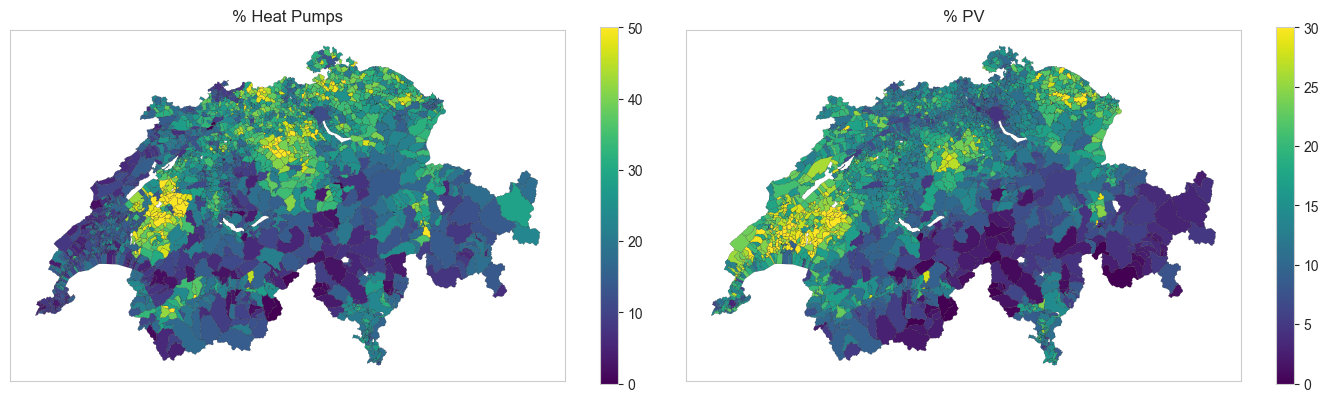

In [36]:
data_m = gdf.pivot_table(index='Municipality', columns='Heating Technology', aggfunc='size', fill_value=0)
data_percentage_m = data_m.div(data_m.sum(axis=1), axis=0) * 100
data_percentage_m = data_percentage_m.reset_index(drop=False)
data_percentage_m = data_percentage_m.merge(municipal_limits, how='left', left_on=['Municipality'], right_on=['NAME'])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

data_HP_percentage_m = data_percentage_m[['Municipality', 'HeatPump', 'geometry']]
data_HP_percentage_m = data_HP_percentage_m.reset_index(drop=False)
gdf_HP_m = gpd.GeoDataFrame(data_HP_percentage_m, crs="EPSG:2056", geometry='geometry')
gdf_HP_m.plot(ax=axes[0], column='HeatPump', legend=True, linewidth=0.1, vmin=0, vmax=50, edgecolor='black', cmap='viridis').set_title('% Heat Pumps')
axes[0].set_xticks([])
axes[0].set_yticks([])

data_m = gdf.pivot_table(index='Municipality', columns='PV', aggfunc='size', fill_value=0)
data_percentage_m = data_m.div(data_m.sum(axis=1), axis=0) * 100
data_percentage_m = data_percentage_m.reset_index(drop=False)
data_percentage_m = data_percentage_m.merge(municipal_limits, how='left', left_on=['Municipality'], right_on=['NAME'])

data_PV_percentage_m = data_percentage_m[['Municipality', 'PVyes', 'geometry']]
data_PV_percentage_m = data_PV_percentage_m.reset_index(drop=False)
gdf_PV_m = gpd.GeoDataFrame(data_PV_percentage_m, crs="EPSG:2056", geometry='geometry')
gdf_PV_m.plot(ax=axes[1], column='PVyes', legend=True, linewidth=0.1, vmin=0, vmax=30, edgecolor='black', cmap='viridis').set_title('% PV')
axes[1].set_xticks([])
axes[1].set_yticks([])

plt.tight_layout()
plt.show()

In [37]:
gdf_regression = gdf_2025_drivers.drop(columns=['Canton', 'District', 'City energy label', 'Operator', 'Comune', 'Heating Technology', 'PV', 'Peer effect PV', 'Peer effect HP']).copy()

Perform the chi-square test of independence between PV and HP for each combination of Canton, Type and Construction Period and check where a significant sign of dependence is present.

In [39]:
def chi_sq_test(data, group_cols):
    """
    Perform chi-square test of independence between PV_binary and HP_binary
    within each combination of the specified group columns.
    """
    results = []

    for group_vals, df_group in data.groupby(group_cols, observed=False):
        ct = pd.crosstab(df_group["PV_binary"], df_group["HP_binary"])

        if ct.shape == (2, 2):
            chi2, p, dof, expected = chi2_contingency(ct)

            if isinstance(group_vals, tuple):
                group_dict = dict(zip(group_cols, group_vals))
            else:
                group_dict = {group_cols[0]: group_vals}

            results.append({
                **group_dict,
                "n_obs": len(df_group),
                "pv_rate": df_group["PV_binary"].mean(),
                "hp_rate": df_group["HP_binary"].mean(),
                "chi2": chi2,
                "p_value": p
            })

    return pd.DataFrame(results)

In [40]:
res_3way = chi_sq_test(gdf_2025_drivers, ["Type", "Canton", "Construction Period"])

## 3.1 PV Stepwise Regression

In [41]:
def stepwise_selection_inference_log(
    data,
    response,
    predictors,
    p_enter=0.05,
    p_remove=0.05,
    selection="AIC"
):
    """
    Stepwise logistic regression for inference:

    Rules:
      - Numeric predictors: must satisfy p-value thresholds (p_enter / p_remove)
      - Categorical predictors (C(var)): ignore p-values, use AIC/BIC only
      - AIC or BIC determines best overall model fit
      - Detailed history saved at every step

    Returns:
       selected predictors list
       history dataframe
    """

    score_attr = "aic" if selection == "AIC" else "bic"
    remaining = predictors.copy()
    selected = []
    current_score = np.inf
    step = 0

    history = []

    def is_categorical(term):
        """Detect whether the predictor is categorical."""
        return term.startswith("C(")

    improved = True
    while improved:
        improved = False

        # ----------------------------------------------------
        # Forward Step
        # ----------------------------------------------------
        forward_candidates = []

        for cand in remaining:
            formula = f"{response} ~ {' + '.join(selected + [cand])}"

            try:
                model = smf.logit(formula, data=data).fit(disp=0)
            except:
                continue

            # If the predictor is categorical → ignore p-value, consider model score only
            if is_categorical(cand):
                forward_candidates.append((getattr(model, score_attr), cand, model))

            else:
                # Numeric variable → must satisfy p_enter
                pval = model.pvalues.get(cand, None)
                if pval is not None and pval < p_enter:
                    forward_candidates.append((getattr(model, score_attr), cand, model))

        # If any valid forward candidate exists
        if forward_candidates:
            best_score, best_cand, best_model = sorted(forward_candidates, key=lambda x: x[0])[0]

            if best_score < current_score:
                selected.append(best_cand)
                print(f"STEP {step}: ADD → {best_cand} (AIC/BIC = {best_score:.3f})")
                remaining.remove(best_cand)
                current_score = best_score
                step += 1
                improved = True

                history.append({
                    "Step": step,
                    "Action": f"ADD {best_cand}",
                    "AIC/BIC": best_score,
                    "Pseudo_R2": 1 - best_model.llf / best_model.llnull,
                    "Included_Predictors": selected.copy(),
                    "P_values": best_model.pvalues.to_dict()
                })

        # Backward Step
        if len(selected) > 0:
            formula = f"{response} ~ {' + '.join(selected)}"
            full_model = smf.logit(formula, data=data).fit(disp=0)

            pvals = full_model.pvalues.drop("Intercept")

            # Determine worst predictor
            scores = []
            for term in selected:
                if is_categorical(term):
                    # Skip p-value filtering → categorical can only be removed if AIC/BIC improves
                    scores.append((term, np.nan))
                else:
                    scores.append((term, pvals.get(term, np.inf)))

            # Get numeric variable with largest p-value
            numeric_terms = [(t, p) for t, p in scores if not is_categorical(t)]
            worst_var = None
            worst_pval = None

            if numeric_terms:
                worst_var, worst_pval = sorted(numeric_terms, key=lambda x: x[1], reverse=True)[0]

            # If worst numeric variable fails significance → remove it
            if worst_var is not None and worst_pval is not None and worst_pval > p_remove:
                selected.remove(worst_var)
                print(f"STEP {step}: REMOVE → {worst_var} (p = {worst_pval:.4f})")
                remaining.append(worst_var)
                step += 1
                improved = True

                # Refit
                if len(selected) > 0:
                    new_formula = f"{response} ~ {' + '.join(selected)}"
                    new_model = smf.logit(new_formula, data=data).fit(disp=0)
                    current_score = getattr(new_model, score_attr)
                    pseudo_r2 = 1 - new_model.llf / new_model.llnull
                    pvals_dict = new_model.pvalues.to_dict()
                else:
                    current_score = np.inf
                    pseudo_r2 = None
                    pvals_dict = {}

                history.append({
                    "Step": step,
                    "Action": f"REMOVE {worst_var}",
                    "AIC/BIC": current_score,
                    "Pseudo_R2": pseudo_r2,
                    "Included_Predictors": selected.copy(),
                    "P_values": pvals_dict
                })

    history_df = pd.DataFrame(history)

    return selected, history_df

In [42]:
def compute_vif(data, predictors):
    """
    Compute VIF for predictors, expanding categorical variables (C()) into dummies.
    """
    formula = " + ".join(predictors)

    X = dmatrix(formula, data=data, return_type='dataframe')

    X = sm.add_constant(X, has_constant='add')

    vif_df = pd.DataFrame()
    vif_df["Variable"] = X.columns
    vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

    return vif_df

In [43]:
gdf_regression['log Area'] = np.log(gdf_regression['Area [m2]'])
gdf_regression['log Mean Income'] = np.log(gdf_regression['Mean Income'])
gdf_regression = gdf_regression.drop(columns=['Area [m2]', 'Mean Income', 'Roof area [m2]']).copy()

In [44]:
gdf_regression = gdf_regression.rename(columns={"Specific Roof Potential [kWh/m2y]": "Specific_Roof_Potential",
                                                "log Area": "log_Area",
                                                "EV share [%]": "EV_share",
                                                "City energy label binary": "City_energy_label",
                                                "Secondary House Rate [%]": "Secondary_House",
                                                "People Over 65 [%]": "People_Over_65",
                                                "People Below 19 [%]": "People_Below_19",
                                                "Foreigners Share [%]": "Foreigners",
                                                "Households Over 5 People [%]": "Households_Over_5_People",
                                                "Population Density": "Population_Density",
                                                "CO2Act Yes Share [%]": "CO2Act_Yes",
                                                "Green party [%]": "Green_party",
                                                "Electricity Price (cts./kWh)": "Electricity_Price",
                                                "log Mean Income": "log_Mean_Income",
                                                "Construction Period": "Construction_Period",
                                                "Area Type": "Area_type",
                                                "Peer effect DH": "Peer_Effect_DH"
                                                })

In [45]:
cols_to_scale = ["Specific_Roof_Potential",
                 "log_Area",
                 "EV_share",
                 "City_energy_label",
                 "Secondary_House",
                 "People_Over_65",
                 "People_Below_19",
                 "Foreigners",
                 "Households_Over_5_People",
                 "Population_Density",
                 "CO2Act_Yes",
                 "Green_party",
                 "Electricity_Price",
                 "log_Mean_Income",
                 "Peer_Effect_DH"
                 ]

scaler = StandardScaler()
gdf_regression[cols_to_scale] = scaler.fit_transform(gdf_regression[cols_to_scale])

In [78]:
pv_predictors = ["Specific_Roof_Potential",
                 "log_Area",
                 "EV_share",
                 "City_energy_label",
                 "Secondary_House",
                 "People_Over_65",
                 "People_Below_19",
                 "Foreigners",
                 "Households_Over_5_People",
                 "Population_Density",
                 "CO2Act_Yes",
                 "Green_party",
                 "Electricity_Price",
                 "log_Mean_Income"
                 ]

all_predictors = pv_predictors + ["HP_binary", "C(Type)", "C(Construction_Period)", "C(Area_type)"]

vif_table = compute_vif(gdf_regression, all_predictors)
print(vif_table)

C:\Users\matteo.palucci\OneDrive - SUPSI\Desktop\Tutto\Teaching\Project 1\SemesterProject\.venv\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


                               Variable       VIF
0                                 const  0.000000
1                             Intercept  0.000000
2                        C(Type)[T.SFH]  1.906997
3   C(Construction_Period)[T.1921-1945]  1.455771
4   C(Construction_Period)[T.1946-1960]  1.465389
5   C(Construction_Period)[T.1961-1970]  1.427690
6   C(Construction_Period)[T.1971-1980]  1.485906
7   C(Construction_Period)[T.1981-1990]  1.494339
8   C(Construction_Period)[T.1991-2000]  1.455330
9   C(Construction_Period)[T.2001-2010]  1.513975
10     C(Construction_Period)[T.> 2010]  1.568433
11                    C(Area_type)[T.2]  1.694393
12                    C(Area_type)[T.3]  2.492386
13              Specific_Roof_Potential  1.116508
14                             log_Area  1.865315
15                             EV_share  2.037434
16                    City_energy_label  1.444556
17                      Secondary_House  2.014137
18                       People_Over_65  2.951710


In [79]:
selected_vars, history_df = stepwise_selection_inference_log(
    data=gdf_regression,
    response="PV_binary",
    predictors=all_predictors,
    p_enter=0.05,
    p_remove=0.05,
    selection="AIC"
)

print("Selected variables:", selected_vars)
history_df.to_pickle("history_df_PV.pkl")

STEP 0: ADD → HP_binary (AIC/BIC = 1272577.090)
STEP 1: ADD → C(Construction_Period) (AIC/BIC = 1260522.257)
STEP 2: ADD → C(Type) (AIC/BIC = 1247903.331)
STEP 3: ADD → People_Below_19 (AIC/BIC = 1240559.424)
STEP 4: ADD → log_Area (AIC/BIC = 1235735.056)
STEP 5: ADD → Green_party (AIC/BIC = 1233009.148)
STEP 6: ADD → Specific_Roof_Potential (AIC/BIC = 1231768.105)
STEP 7: ADD → Electricity_Price (AIC/BIC = 1230546.459)
STEP 8: ADD → Secondary_House (AIC/BIC = 1229668.909)
STEP 9: ADD → Population_Density (AIC/BIC = 1228472.539)
STEP 10: ADD → log_Mean_Income (AIC/BIC = 1227878.292)
STEP 11: ADD → Foreigners (AIC/BIC = 1227543.160)
STEP 12: ADD → EV_share (AIC/BIC = 1227348.360)
STEP 13: ADD → People_Over_65 (AIC/BIC = 1227241.331)
STEP 14: ADD → Households_Over_5_People (AIC/BIC = 1227227.084)
STEP 15: ADD → C(Area_type) (AIC/BIC = 1227211.436)
STEP 16: ADD → City_energy_label (AIC/BIC = 1227198.354)
STEP 17: ADD → CO2Act_Yes (AIC/BIC = 1227191.516)
Selected variables: ['HP_binary', '

In [46]:
selected_vars_with_HP = ['HP_binary', 'C(Construction_Period)', 'C(Type)', 'People_Below_19', 'log_Area', 'Green_party', 'Specific_Roof_Potential', 'Electricity_Price', 'Secondary_House', 'Population_Density', 'log_Mean_Income', 'Foreigners', 'EV_share', 'People_Over_65', 'Households_Over_5_People', 'C(Area_type)', 'City_energy_label', 'CO2Act_Yes']

final_formula = "PV_binary ~ " + " + ".join(selected_vars_with_HP)
final_model = smf.logit(final_formula, data=gdf_regression).fit()
print(final_model.summary())

final_model.save("final_model_PV_with_HP.pickle")

Optimization terminated successfully.
         Current function value: 0.363896
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:              PV_binary   No. Observations:              1686112
Model:                          Logit   Df Residuals:                  1686085
Method:                           MLE   Df Model:                           26
Date:                Fri, 12 Dec 2025   Pseudo R-squ.:                 0.09561
Time:                        14:19:57   Log-Likelihood:            -6.1357e+05
converged:                       True   LL-Null:                   -6.7843e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
Intercept                              -3.5564      0.011 

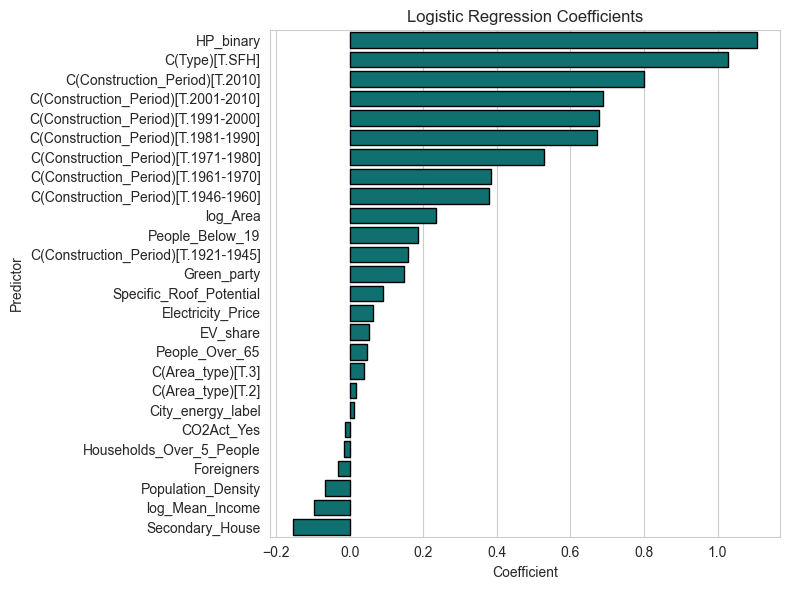

In [52]:
coef = final_model.params
coef_df = pd.DataFrame({
    "Predictor": coef.index,
    "Coefficient": coef.values
})

coef_df = coef_df.loc[coef_df["Predictor"]!="Intercept"].copy()
coef_df = coef_df.sort_values("Coefficient", ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(
    data=coef_df,
    x="Coefficient",
    y="Predictor",
    color="teal",
    edgecolor="black"
)

plt.title("Logistic Regression Coefficients")
plt.tight_layout()
plt.show()

In [47]:
selected_vars_no_HP = ['C(Construction_Period)', 'C(Type)', 'People_Below_19', 'log_Area', 'Green_party', 'Specific_Roof_Potential', 'Electricity_Price', 'Secondary_House', 'Population_Density', 'log_Mean_Income', 'Foreigners', 'EV_share', 'People_Over_65', 'Households_Over_5_People', 'C(Area_type)', 'City_energy_label', 'CO2Act_Yes']

final_formula = "PV_binary ~ " + " + ".join(selected_vars_no_HP)
final_model_no_HP = smf.logit(final_formula, data=gdf_regression).fit()
print(final_model_no_HP.summary())

final_model_no_HP.save("final_model_PV_no_HP.pickle")

Optimization terminated successfully.
         Current function value: 0.376548
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:              PV_binary   No. Observations:              1686112
Model:                          Logit   Df Residuals:                  1686086
Method:                           MLE   Df Model:                           25
Date:                Fri, 12 Dec 2025   Pseudo R-squ.:                 0.06417
Time:                        14:20:43   Log-Likelihood:            -6.3490e+05
converged:                       True   LL-Null:                   -6.7843e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
Intercept                              -3.5223      0.011 

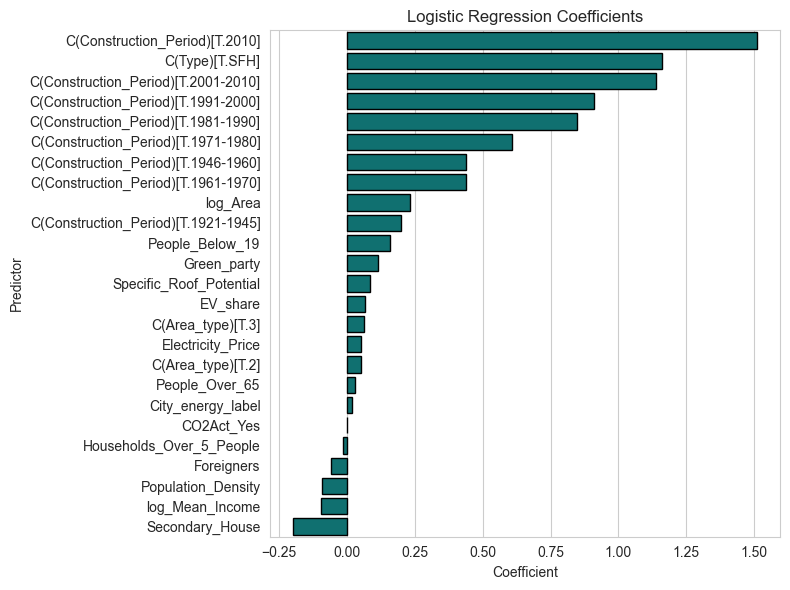

In [53]:
coef = final_model_no_HP.params
coef_df = pd.DataFrame({
    "Predictor": coef.index,
    "Coefficient": coef.values
})

coef_df = coef_df.loc[coef_df["Predictor"]!="Intercept"].copy()
coef_df = coef_df.sort_values("Coefficient", ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(
    data=coef_df,
    x="Coefficient",
    y="Predictor",
    color="teal",
    edgecolor="black"
)

plt.title("Logistic Regression Coefficients")
plt.tight_layout()
plt.show()

In [70]:
loaded_model = sm.load(notebook_dir + "/final_model_PV.pickle")
print(loaded_model.summary())

                           Logit Regression Results                           
Dep. Variable:              PV_binary   No. Observations:              1686112
Model:                          Logit   Df Residuals:                  1686085
Method:                           MLE   Df Model:                           26
Date:                Thu, 11 Dec 2025   Pseudo R-squ.:                 0.09561
Time:                        21:13:07   Log-Likelihood:            -6.1357e+05
converged:                       True   LL-Null:                   -6.7843e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
Intercept                              -3.5564      0.011   -319.606      0.000      -3.578      -3.535
C(Type)[T.SFH]                          1.0279      0.00

## 3.2 HP Stepwise Regression

In [81]:
hp_predictors = ["log_Area",
                 "EV_share",
                 "City_energy_label",
                 "Secondary_House",
                 "People_Over_65",
                 "People_Below_19",
                 "Foreigners",
                 "Households_Over_5_People",
                 "Population_Density",
                 "CO2Act_Yes",
                 "Green_party",
                 "Electricity_Price",
                 "log_Mean_Income",
                 "Peer_Effect_DH"
                 ]

all_predictors = hp_predictors + ["PV_binary", "C(Type)", "C(Construction_Period)", "C(Area_type)"]

vif_table = compute_vif(gdf_regression, all_predictors)
print(vif_table)

C:\Users\matteo.palucci\OneDrive - SUPSI\Desktop\Tutto\Teaching\Project 1\SemesterProject\.venv\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


                               Variable       VIF
0                                 const  0.000000
1                             Intercept  0.000000
2                        C(Type)[T.SFH]  1.913405
3   C(Construction_Period)[T.1921-1945]  1.455633
4   C(Construction_Period)[T.1946-1960]  1.450199
5   C(Construction_Period)[T.1961-1970]  1.396045
6   C(Construction_Period)[T.1971-1980]  1.446415
7   C(Construction_Period)[T.1981-1990]  1.465133
8   C(Construction_Period)[T.1991-2000]  1.426068
9   C(Construction_Period)[T.2001-2010]  1.413207
10     C(Construction_Period)[T.> 2010]  1.377971
11                    C(Area_type)[T.2]  1.702242
12                    C(Area_type)[T.3]  2.503974
13                             log_Area  1.867339
14                             EV_share  2.044918
15                    City_energy_label  1.466296
16                      Secondary_House  1.970590
17                       People_Over_65  2.949930
18                      People_Below_19  3.621498


In [82]:
selected_vars, history_df = stepwise_selection_inference_log(
    data=gdf_regression,
    response="HP_binary",
    predictors=all_predictors,
    p_enter=0.05,
    p_remove=0.05,
    selection="AIC"
)

print("Selected variables:", selected_vars)
history_df.to_pickle("history_df_HP.pkl")

STEP 0: ADD → C(Construction_Period) (AIC/BIC = 1561186.781)
STEP 1: ADD → PV_binary (AIC/BIC = 1509636.309)
STEP 2: ADD → C(Type) (AIC/BIC = 1490880.845)
STEP 3: ADD → Secondary_House (AIC/BIC = 1483441.583)
STEP 4: ADD → Population_Density (AIC/BIC = 1475679.808)
STEP 5: ADD → Foreigners (AIC/BIC = 1473251.947)
STEP 6: ADD → EV_share (AIC/BIC = 1471083.029)
STEP 7: ADD → Green_party (AIC/BIC = 1468637.533)
STEP 8: ADD → Electricity_Price (AIC/BIC = 1467481.515)
STEP 9: ADD → Peer_Effect_DH (AIC/BIC = 1466341.167)
STEP 10: ADD → People_Below_19 (AIC/BIC = 1465445.524)
STEP 11: ADD → C(Area_type) (AIC/BIC = 1464744.028)
STEP 12: ADD → CO2Act_Yes (AIC/BIC = 1464324.652)
STEP 13: ADD → City_energy_label (AIC/BIC = 1464033.769)
STEP 14: ADD → People_Over_65 (AIC/BIC = 1463822.539)
STEP 15: ADD → Households_Over_5_People (AIC/BIC = 1463810.798)
STEP 16: ADD → log_Mean_Income (AIC/BIC = 1463801.021)
Selected variables: ['C(Construction_Period)', 'PV_binary', 'C(Type)', 'Secondary_House', 'P

In [55]:
selected_vars_with_PV = ['C(Construction_Period)', 'PV_binary', 'C(Type)', 'Secondary_House', 'Population_Density', 'Foreigners', 'EV_share', 'Green_party', 'Electricity_Price', 'Peer_Effect_DH', 'People_Below_19', 'C(Area_type)', 'CO2Act_Yes', 'City_energy_label', 'People_Over_65', 'Households_Over_5_People', 'log_Mean_Income']

final_formula = "HP_binary ~ " + " + ".join(selected_vars_with_PV)
final_model = smf.logit(final_formula, data=gdf_regression).fit()
print(final_model.summary())

final_model.save("final_model_HP_with_PV.pickle")

Optimization terminated successfully.
         Current function value: 0.434060
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:              HP_binary   No. Observations:              1686112
Model:                          Logit   Df Residuals:                  1686086
Method:                           MLE   Df Model:                           25
Date:                Fri, 12 Dec 2025   Pseudo R-squ.:                  0.2069
Time:                        14:32:51   Log-Likelihood:            -7.3187e+05
converged:                       True   LL-Null:                   -9.2282e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
Intercept                              -2.9665      0.008 

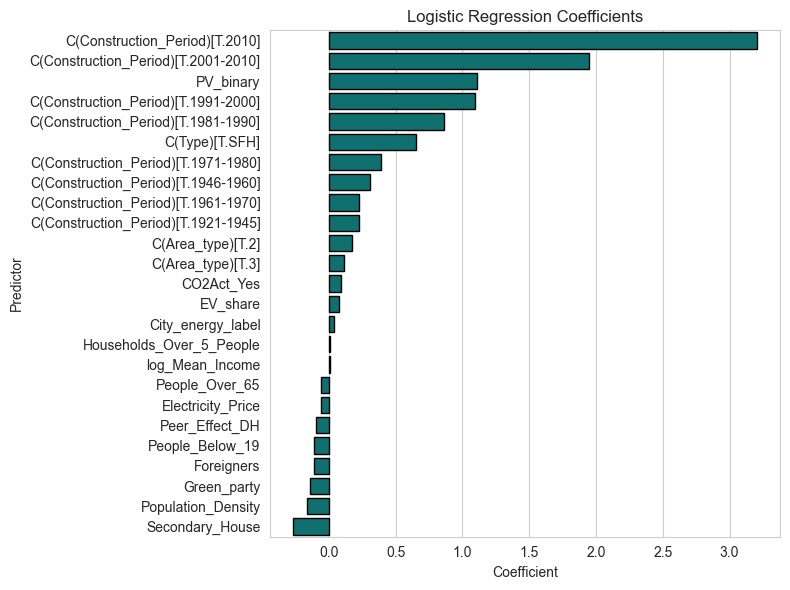

In [56]:
coef = final_model.params
coef_df = pd.DataFrame({
    "Predictor": coef.index,
    "Coefficient": coef.values
})

coef_df = coef_df.loc[coef_df["Predictor"]!="Intercept"].copy()
coef_df = coef_df.sort_values("Coefficient", ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(
    data=coef_df,
    x="Coefficient",
    y="Predictor",
    color="teal",
    edgecolor="black"
)

plt.title("Logistic Regression Coefficients")
plt.tight_layout()
plt.show()

In [57]:
selected_vars_no_PV = ['C(Construction_Period)', 'C(Type)', 'Secondary_House', 'Population_Density', 'Foreigners', 'EV_share', 'Green_party', 'Electricity_Price', 'Peer_Effect_DH', 'People_Below_19', 'C(Area_type)', 'CO2Act_Yes', 'City_energy_label', 'People_Over_65', 'Households_Over_5_People', 'log_Mean_Income']

final_formula = "HP_binary ~ " + " + ".join(selected_vars_no_PV)
final_model = smf.logit(final_formula, data=gdf_regression).fit()
print(final_model.summary())

final_model.save("final_model_HP_no_PV.pickle")

Optimization terminated successfully.
         Current function value: 0.446715
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:              HP_binary   No. Observations:              1686112
Model:                          Logit   Df Residuals:                  1686087
Method:                           MLE   Df Model:                           24
Date:                Fri, 12 Dec 2025   Pseudo R-squ.:                  0.1838
Time:                        14:36:43   Log-Likelihood:            -7.5321e+05
converged:                       True   LL-Null:                   -9.2282e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
Intercept                              -2.9228      0.008 

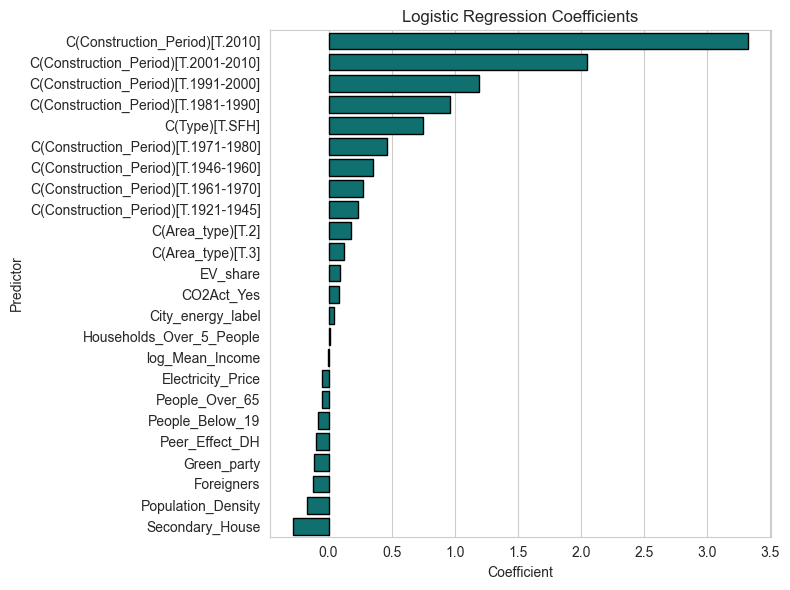

In [58]:
coef = final_model.params
coef_df = pd.DataFrame({
    "Predictor": coef.index,
    "Coefficient": coef.values
})

coef_df = coef_df.loc[coef_df["Predictor"]!="Intercept"].copy()
coef_df = coef_df.sort_values("Coefficient", ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(
    data=coef_df,
    x="Coefficient",
    y="Predictor",
    color="teal",
    edgecolor="black"
)

plt.title("Logistic Regression Coefficients")
plt.tight_layout()
plt.show()